# Pool Ball Detection - Task 1

## Step 1: Initialization and Data Loading
This section imports the allowed libraries and loads the pool table images specified in the input JSON file.

### 1.1 Load Libraries

In [40]:
import json
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt


### 1.2 Data Ingestion
Reads the JSON input and loads images into a dictionary, converting them to RGB.

In [41]:
json_file = "input.json" 
loaded_images = {}

with open(json_file, 'r') as f:
    data = json.load(f)

image_list = data.get("image_path", []) if isinstance(data, dict) else data

for full_path in image_list:
    img_bgr = cv2.imread(full_path)
    
    if img_bgr is not None:
        clean_name = os.path.basename(full_path)
        
        loaded_images[clean_name] = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

print(f"Loaded {len(loaded_images)} images.")

Loaded 50 images.


### 1.3 Sanity Check
Displays 3 random images to verify everything loaded correctly.

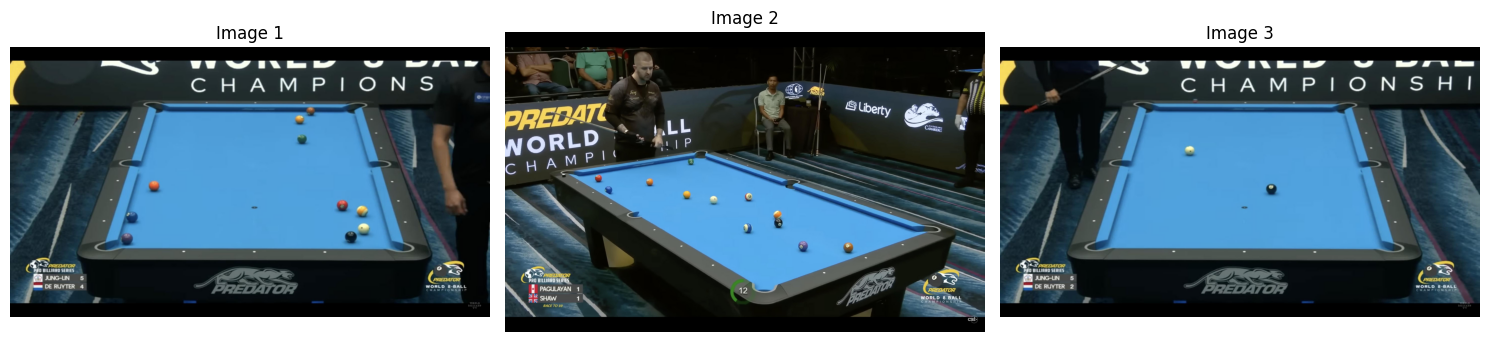

In [42]:
image_paths = list(loaded_images.keys())

first_three_images = image_paths[:3]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
i = 1
for ax, key in zip(axes, first_three_images):
    ax.imshow(loaded_images[key])
    ax.set_title(f"Image {i}", color='black')
    ax.axis('off')
    i += 1

plt.tight_layout()
plt.show()

### 1.4 Define Test Image Variable

In [43]:
test_key = random.choice(image_paths)  
test_img = loaded_images[test_key]

## Step 2: Top Down View

### 2.1 Table Area Detection
To warp the image, we first need to isolate the playing surface from the background. Instead of hardcoding colors, this function dynamically samples the color at the center of the image. It then uses computer vision techniques (dilation, convex hulls, and erosion) to swallow up the pool balls, straighten the pocket edges, and output a clean, solid mask of just the playable area.


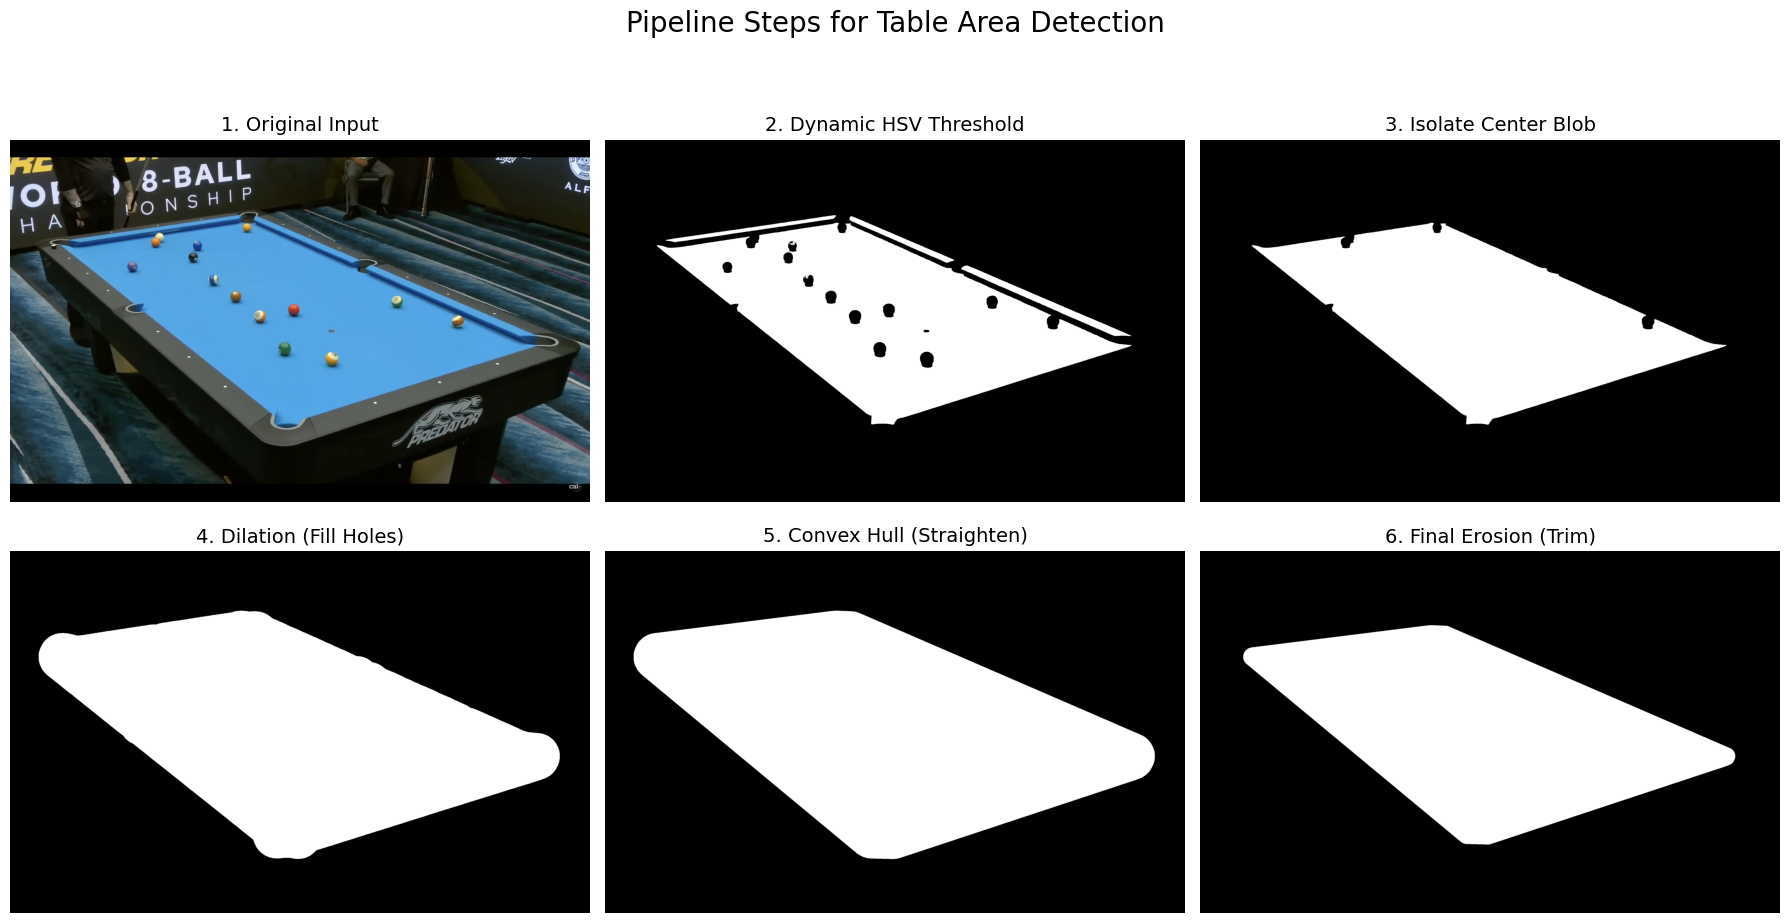

In [44]:
mask_steps = {}
# Function to get the table area
def get_table_mask(image_rgb):
    # Samples the color of the center pixel to create a mask of the table, then refines it by``
    # filling internal gaps, and wrapping it in a convex polygon.
    mask_steps['0_original'] = image_rgb.copy()
    
    img_h, img_w = image_rgb.shape[:2]
    
    # Blur to reduce noise and convert to HSV for color isolation
    blurred = cv2.GaussianBlur(image_rgb, (7, 7), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
    
    cx, cy = img_w // 2, img_h // 2

    # 1. Dynamic Color Sampling
    # Define rectangular patch size from image dimensions 
    patch_h = int(img_h * 0.1) 
    patch_w = int(img_w * 0.2)
    
    # Grab the dynamic rectangular patch around the center pixel
    center_patch = hsv[cy - patch_h : cy + patch_h, cx - patch_w : cx + patch_w]
    
    # Calculate the median Hue, Saturation, and Value of the center cloth
    h_med = int(np.median(center_patch[:, :, 0]))
    s_med = int(np.median(center_patch[:, :, 1]))
    v_med = int(np.median(center_patch[:, :, 2]))

    # Create a tight boundary around that specific median color
    lower_bound = (max(0, h_med - 12), max(60, s_med - 50), max(100, v_med - 60))
    upper_bound = (min(180, h_med + 12), 255, 255)
    
    raw_cloth_mask = cv2.inRange(hsv, lower_bound, upper_bound)

    mask_steps['1_hsv_threshold'] = raw_cloth_mask.copy()
    
    # 2. Isolate the True Table Blob
    contours, _ = cv2.findContours(raw_cloth_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros((img_h, img_w), dtype=np.uint8)

    table_contour = None
    
    # Check the 5 largest blobs. Pick the one that covers the center pixel.
    largest_contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]
    for contour in largest_contours:
        if cv2.pointPolygonTest(contour, (cx, cy), False) >= 0:
            table_contour = contour
            break
            
    # Fallback: If center is somehow missed (e.g., covered by a ball), pick the largest blob
    if table_contour is None:
        table_contour = max(contours, key=cv2.contourArea)

    isolated_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(isolated_mask, [table_contour], -1, 255, cv2.FILLED)
    
    mask_steps['2_isolated_center_blob'] = isolated_mask.copy()

    # 3. Dilation (Fill Holes)
    # Draw the raw contour onto a blank canvas
    working_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(working_mask, [table_contour], -1, 255, cv2.FILLED)
    

    # Grow the white pixels to swallow balls and shadows
    kernel_size = max(25, img_w // 50)
    dilation_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size*2+1, kernel_size*2+1))
    working_mask = cv2.dilate(working_mask, dilation_kernel, iterations=2)

    mask_steps['3_dilated_solid_blob'] = working_mask.copy()
    
    # 4. Convex Hull (Straighten Edges)
    contours_dilated, _ = cv2.findContours(working_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_dilated = max(contours_dilated, key=cv2.contourArea)
    
    
    hull = cv2.convexHull(largest_dilated)
    
    solid_polygon_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.fillPoly(solid_polygon_mask, [hull], 255)

    mask_steps['4_geometric_convex_hull'] = solid_polygon_mask.copy()
    
    # 5. Erosion (Make edges Sharper by removing a small border)
    erosion_padding = max(4, int(min(img_h, img_w) * 0.020))
    erosion_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erosion_padding*2+1, erosion_padding*2+1))
    final_table_mask = cv2.erode(solid_polygon_mask, erosion_kernel, iterations=2)
    
    mask_steps['5_final_eroded_surface'] = final_table_mask.copy()
    
    return final_table_mask

# ═══════════════════════════════════════════════════════════════
#  Visualization Pipeline
# ═══════════════════════════════════════════════════════════════

final_mask = get_table_mask(test_img)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel() 

step_keys = sorted(mask_steps.keys())

titles = [
    "1. Original Input",
    "2. Dynamic HSV Threshold",
    "3. Isolate Center Blob",
    "4. Dilation (Fill Holes)",
    "5. Convex Hull (Straighten)",
    "6. Final Erosion (Trim)"
]

for i in range(len(step_keys)):
    key = step_keys[i]
    display_img = mask_steps[key]
    
    if len(display_img.shape) == 3: 
        axes[i].imshow(display_img)
    else: 
        axes[i].imshow(display_img, cmap='gray')
        
    axes[i].set_title(titles[i], color='black', fontsize=14)
    axes[i].axis('off') 

plt.suptitle("Pipeline Steps for Table Area Detection", fontsize=20, color='black')
plt.tight_layout(rect=[0, 0.01, 1, 0.96]) 
plt.show()


### 2.1.1 Check Mask Overlay

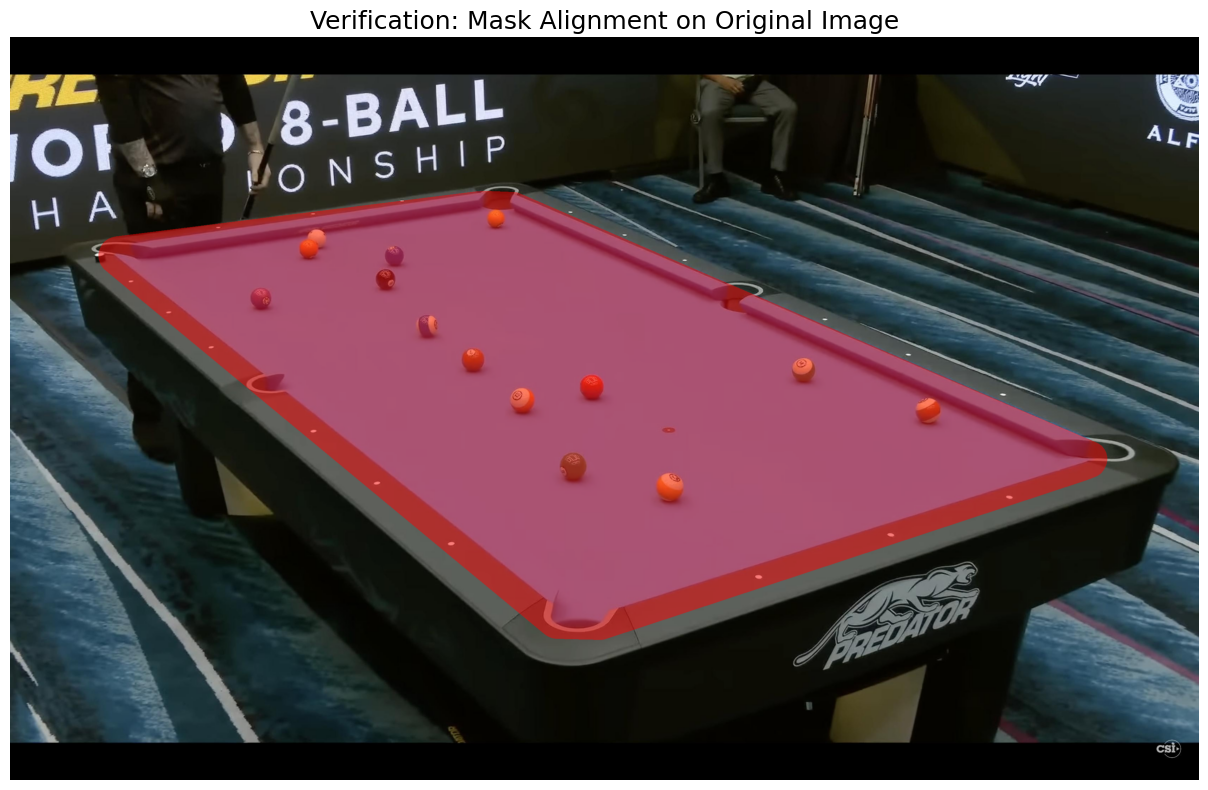

In [45]:
# Red Verification Overlay 
red_layer = np.zeros_like(test_img)
red_layer[:] = (255, 0, 0) 

blended_img = cv2.addWeighted(test_img, 0.5, red_layer, 0.5, 0)

overlay_img = np.where(final_mask[..., None] == 255, blended_img, test_img)

plt.figure(figsize=(14, 8))
plt.imshow(overlay_img)
plt.title("Verification: Mask Alignment on Original Image", fontsize=18, color='black')
plt.axis('off')
plt.tight_layout()
plt.show()

### 2.2 Table Corner Extraction
Because our table mask has slightly rounded corners, we cannot simply look for the "tips" of the shape. Instead, this function finds the four straight sides of the table, draws mathematically perfect lines through them, and calculates exactly where those lines cross to find the true, sharp corners.

In [46]:
# ═══════════════════════════════════════════════════════════════
#  Helper Functions
# ═══════════════════════════════════════════════════════════════

# Sorts corners using the center point as reference 
def order_points_clockwise(pts):
    cx, cy = np.mean(pts, axis=0)
    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    sorted_pts = pts[np.argsort(angles)]
    
    s = sorted_pts.sum(axis=1)
    tl_index = np.argmin(s)
    return np.roll(sorted_pts, shift=-tl_index, axis=0)

# Line intersection function (returns a point if possible, None if parallel)
def intersect_lines(l1, l2):
    vx1, vy1, x1, y1 = l1
    vx2, vy2, x2, y2 = l2
    
    A1, B1 = vy1, -vx1
    C1 = vy1 * x1 - vx1 * y1
    
    A2, B2 = vy2, -vx2
    C2 = vy2 * x2 - vx2 * y2
    
    det = A1 * B2 - A2 * B1
    if abs(det) < 1e-6:
        return None 
        
    x = (C1 * B2 - C2 * B1) / det
    y = (A1 * C2 - A2 * C1) / det
    return [x, y]

def draw_infinite_line(img, line, color, thickness=2):
    vx, vy, x, y = line
    mult = 3000
    p1 = (int(x - mult * vx), int(y - mult * vy))
    p2 = (int(x + mult * vx), int(y + mult * vy))
    cv2.line(img, p1, p2, color, thickness)

corner_steps = {}

def get_corners_from_mask(table_mask):
    # For visualization purposes
    mask_rgb = cv2.cvtColor(table_mask, cv2.COLOR_GRAY2RGB)

    cnts, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None
        
    largest_contour = max(cnts, key=cv2.contourArea)
    peri = cv2.arcLength(largest_contour, True)
    
    # Get corner points using approxPolyDP to find 4 corners
    guide_corners = None
    for eps_multiplier in np.linspace(0.005, 0.2, 100):
        epsilon = eps_multiplier * peri
        approx = cv2.approxPolyDP(largest_contour, epsilon, True)
        if len(approx) == 4 and cv2.isContourConvex(approx):
            guide_corners = approx.reshape(4, 2).astype("float32")
            break
            
    if guide_corners is None: return None
    
    # Order the guideposts: 0:TL, 1:TR, 2:BR, 3:BL
    ordered_guides = order_points_clockwise(guide_corners)
    
    # Image 1: Show guideposts on the mask
    step1_img = mask_rgb.copy()
    cv2.polylines(step1_img, [np.int32(ordered_guides)], True, (255, 255, 0), 2)
    for pt in ordered_guides:
        cv2.circle(step1_img, (int(pt[0]), int(pt[1])), 15, (255, 0, 0), -1)
    corner_steps['1_guideposts'] = step1_img


    pts = largest_contour.reshape(-1, 2)
    edge_points = [[], [], [], []]
    
    # Assign every pixel to one of the 4 edges
    for pt in pts:
        min_dist = float('inf')
        best_edge = -1
        for i in range(4):
            p1 = ordered_guides[i]
            p2 = ordered_guides[(i + 1) % 4]
            l2 = np.sum((p1 - p2)**2)
            if l2 == 0: continue
            t = max(0, min(1, np.dot(pt - p1, p2 - p1) / l2))
            proj = p1 + t * (p2 - p1)
            dist = np.linalg.norm(pt - proj)
            if dist < min_dist:
                min_dist = dist
                best_edge = i
        edge_points[best_edge].append(pt)
    
    # Image 2: Show edge pixels colored by assigned edge
    step2_img = np.zeros_like(mask_rgb)
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)] 
    for i in range(4):
        for pt in edge_points[i]:
            cv2.circle(step2_img, tuple(pt), 5, colors[i], -1)
    corner_steps['2_edge_pixels'] = step2_img


    # Fit a line to each edge
    fitted_lines = []
    step3_img = mask_rgb.copy()
    
    for i in range(4):
        ep = np.array(edge_points[i])
        if len(ep) < 10: return None
        
        p1 = ordered_guides[i]
        dists = np.linalg.norm(ep - p1, axis=1)
        ep_sorted = ep[np.argsort(dists)]
        
        trim = int(len(ep_sorted) * 0.15)
        if trim > 0:
            ep_trimmed = ep_sorted[trim:-trim]
        else:
            ep_trimmed = ep_sorted
        for pt in ep_trimmed:
            cv2.circle(step3_img, tuple(pt), 5, (255, 0, 255), -1)
            
        [vx, vy, x, y] = cv2.fitLine(ep_trimmed, cv2.DIST_L2, 0, 0.01, 0.01)
        line = (vx[0], vy[0], x[0], y[0])
        fitted_lines.append(line)
        
        draw_infinite_line(step3_img, line, colors[i], 2)
        
    # Image 3: Show fitted lines on the mask
    corner_steps['3_fitted_lines'] = step3_img

    # Intersect the 4 lines to get the new corners
    tl = intersect_lines(fitted_lines[0], fitted_lines[3]) # Top intersects Left
    tr = intersect_lines(fitted_lines[0], fitted_lines[1]) # Top intersects Right
    br = intersect_lines(fitted_lines[1], fitted_lines[2]) # Right intersects Bottom
    bl = intersect_lines(fitted_lines[2], fitted_lines[3]) # Bottom intersects Left
    
    if None in (tl, tr, br, bl): return None
    
    step4_img = mask_rgb.copy()

    final_corners = np.array([tl, tr, br, bl], dtype="float32")
    
    for pt in final_corners:
        cv2.circle(step4_img, (int(pt[0]), int(pt[1])), 15, (255, 0, 255), -1)
    corner_steps['4_intersections'] = step4_img

    return final_corners



#  Run the Visualization

test_mask = get_table_mask(test_img)

raw_corners = get_corners_from_mask(test_mask)

if raw_corners is not None:
    ordered_corners = order_points_clockwise(raw_corners)
    
    final_display_img = test_img.copy()
    colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)] 
    for i, pt in enumerate(ordered_corners):
        cv2.circle(final_display_img, (int(pt[0]), int(pt[1])), 15, colors[i], -1)
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.ravel() 
    
    titles = [
        "1. Guideposts (approxPolyDP)", 
        "2. Grouping the Edge Pixels", 
        "3. Trimming Curves & Fitting Lines", 
        "4. Exact Mathematical Intersections",
        "5. Final Result on Original Image"
    ]
    
    images_to_show = [
        corner_steps['1_guideposts'], 
        corner_steps['2_edge_pixels'], 
        corner_steps['3_fitted_lines'], 
        corner_steps['4_intersections'],
        final_display_img
    ]
    
    for i in range(5):
        axes[i].imshow(images_to_show[i])
        axes[i].set_title(titles[i], color='black', fontsize=14, pad=10)
        axes[i].axis('off')

    axes[5].axis('off')

    plt.suptitle("Hybrid Corner Extraction Pipeline", fontsize=20, color='black')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("Could not find corners to visualize.")

KeyboardInterrupt: 

### 2.3 Table Warping Pipeline

In [ ]:
# Warps the 4 corners into an horizontal top-down view.
# Returns the warped image AND the transformation matrix (M) needed for backtracking.
def warp_to_top_down(image_rgb, ordered_corners, width=1200, height=800):
    top_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[1])
    left_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[3])
    
    ratio = top_edge / left_edge
    
    if ratio < 1.8:
        # END-VIEW mapping
        dst_pts = np.array([
            [0, 0],                  
            [0, height - 1],         
            [width - 1, height - 1], 
            [width - 1, 0]           
        ], dtype="float32")
    else:
        # SIDE-VIEW mapping
        dst_pts = np.array([
            [0, 0],                  
            [width - 1, 0],          
            [width - 1, height - 1], 
            [0, height - 1]          
        ], dtype="float32")

    # M is the mathematical map from Original -> Flat
    M = cv2.getPerspectiveTransform(ordered_corners, dst_pts)

    warped = cv2.warpPerspective(image_rgb, M, (width, height), borderMode=cv2.BORDER_REPLICATE)
    
    return warped, M

test_mask = get_table_mask(test_img)

raw_corners = get_corners_from_mask(test_mask)

if raw_corners is not None:
    ordered_corners = order_points_clockwise(raw_corners)

corner_img = test_img.copy()
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0)]
for i, pt in enumerate(ordered_corners):
    cv2.circle(corner_img, (int(pt[0]), int(pt[1])), 15, colors[i], -1)
    
warped_img, warped_Mtx = warp_to_top_down(test_img, ordered_corners)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.imshow(test_mask, cmap='gray')
ax1.set_title("1. Generated Table Mask", fontsize=16, color='black')
ax1.axis('off')

ax2.imshow(corner_img)
ax2.set_title("2. Extracted Geometric Corners", fontsize=16, color='black')
ax2.axis('off')

ax3.imshow(warped_img)
ax3.set_title("3. Final Top-Down Warp", fontsize=16, color='black')
ax3.axis('off')

plt.suptitle("End-to-End Pipeline Summary", fontsize=20, weight='bold', color='black')
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

### 2.4 Save Table Warping Images

In [ ]:
save_outputs = False

if save_outputs:
    # Save warped images
    output_folder = "output"
    os.makedirs(output_folder, exist_ok=True)

    print(f"Starting batch process. Saving top-down images to '{output_folder}'...")

    success_count = 0
    fail_count = 0

    homography_matrices = {}

    for filename, img_rgb in loaded_images.items():
        test_mask = get_table_mask(img_rgb)
        raw_corners = get_corners_from_mask(test_mask)
        
        if raw_corners is not None:
            ordered_corners = order_points_clockwise(raw_corners)
            
            warped_img, M = warp_to_top_down(img_rgb, ordered_corners)
            
            homography_matrices[filename] = M
            
            warped_bgr = cv2.cvtColor(warped_img, cv2.COLOR_RGB2BGR)
            save_path = os.path.join(output_folder, filename)
            cv2.imwrite(save_path, warped_bgr)
            
            success_count += 1
        else:
            print(f"Warning: Could not find corners for {filename}")
            fail_count += 1

    print(f"Batch complete! Warped {success_count} images. ({fail_count} failed)")
    print(f"Successfully saved {len(homography_matrices)} matrices for backtracking.")

# Other

In [49]:
import cv2
import numpy as np

# ─── Pool ball colour definitions (HSV) ──────────────────────────────────────
# Each entry: (ball_number, name, hue_low, hue_high, sat_min, val_min, val_max)
# White/stripe is handled via a separate whiteness ratio check.
# Ball  0 = cue ball (white)
# Balls 1–7  = solid colours
# Ball  8    = black
# Balls 9–15 = same colours as 1–7 but striped (>40% white pixels)

BALL_PROFILES = [
    # num  name        hL   hH  sMin  vMin  vMax
    (1,  "yellow",      20,  35, 100, 100, 255),
    (2,  "blue",       100, 130, 100,  60, 220),
    (3,  "red",          0,  10, 120,  80, 220),
    (4,  "purple",     130, 160, 100,  50, 200),
    (5,  "orange",      10,  22, 150, 100, 240),
    (6,  "green",       40,  85, 100,  40, 200),
    (7,  "maroon",       0,  10, 120,  40,  90),
    (8,  "black",        0, 180,   0,   0,  60),
    # 9–15 share profiles with 1–7 but are identified by stripe_ratio
]
STRIPE_OFFSET = 8  # ball 9 = ball 1 + 8, etc.
WHITE_BALL_ID = 0

# ─── Helpers ─────────────────────────────────────────────────────────────────

def _extract_ball_roi(img_bgr: np.ndarray, cx: float, cy: float, r: float) -> np.ndarray:
    """Return a tight square crop (BGR) around the ball, zero-padded if near edge."""
    x, y, rad = int(round(cx)), int(round(cy)), int(round(r))
    h, w = img_bgr.shape[:2]
    x1, y1 = max(x - rad, 0), max(y - rad, 0)
    x2, y2 = min(x + rad, w),  min(y + rad, h)
    return img_bgr[y1:y2, x1:x2].copy()


def _circular_mask(roi: np.ndarray, cx: float, cy: float, r: float) -> np.ndarray:
    """Boolean mask — True inside the circle, clipped to roi dimensions."""
    rh, rw = roi.shape[:2]
    Y, X = np.ogrid[:rh, :rw]
    # roi starts at (cx-r, cy-r) in image coords; centre in roi coords is (r, r)
    rad = int(round(r))
    return (X - rad) ** 2 + (Y - rad) ** 2 <= rad ** 2


def _pixel_stats(roi_bgr: np.ndarray, mask: np.ndarray):
    """
    Returns:
        white_ratio  – fraction of ball pixels that are white/near-white
        color_hsv    – median H, S, V of the *non-white* ball pixels (or None)
    """
    roi_hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)

    ball_pixels_hsv = roi_hsv[mask]
    if ball_pixels_hsv.size == 0:
        return 0.0, None

    # White: low saturation AND high value
    is_white = (ball_pixels_hsv[:, 1] < 60) & (ball_pixels_hsv[:, 2] > 180)
    white_ratio = float(is_white.sum()) / len(ball_pixels_hsv)

    colored = ball_pixels_hsv[~is_white]
    if colored.size == 0:
        return white_ratio, None

    median_hsv = np.median(colored, axis=0)
    return white_ratio, median_hsv


def _score_profile(h, s, v, profile):
    """Return a match score (lower = better) for a single colour profile."""
    _, _, hL, hH, sMin, vMin, vMax = profile
    h_ok = hL <= h <= hH
    s_ok = s >= sMin
    v_ok = vMin <= v <= vMax
    if not (h_ok and s_ok and v_ok):
        return float("inf")
    # Prefer centre of hue range, higher saturation
    h_centre = (hL + hH) / 2
    score = abs(h - h_centre) + (255 - s) * 0.1
    return score


def _best_profile(median_hsv, white_ratio):
    """
    Given HSV stats, return (base_number, is_stripe) or (WHITE_BALL_ID, False).
    """
    if white_ratio > 0.85:
        return WHITE_BALL_ID, False          # cue ball

    if median_hsv is None:
        return 8, False                      # very dark → black ball

    h, s, v = float(median_hsv[0]), float(median_hsv[1]), float(median_hsv[2])

    # Black ball: median value very low
    if v < 55:
        return 8, False

    best_num, best_score = 8, float("inf")
    for profile in BALL_PROFILES:
        if profile[0] == 8:
            continue
        sc = _score_profile(h, s, v, profile)
        if sc < best_score:
            best_score, best_num = sc, profile[0]

    is_stripe = white_ratio > 0.30          # stripes show ≥30 % white
    return best_num, is_stripe


def _candidate_id(base_num: int, is_stripe: bool) -> int:
    """Convert (base_number, stripe) to a pool ball ID 0–15."""
    if base_num == WHITE_BALL_ID:
        return 0
    if base_num == 8:
        return 8
    return base_num + STRIPE_OFFSET if is_stripe else base_num


# ─── Confidence helper ───────────────────────────────────────────────────────

def _confidence(white_ratio: float, median_hsv) -> float:
    """Rough confidence 0–1 for this detection."""
    if median_hsv is None:
        return 0.5
    s = float(median_hsv[1]) / 255.0
    # High saturation + extreme white_ratio both signal a clean read
    return min(1.0, s * 0.7 + abs(white_ratio - 0.5) * 0.6)


# ─── Main public function ────────────────────────────────────────────────────

def identify_balls(
    all_balls: list,
    ball_r: float,
    img: np.ndarray,           # BGR image (as returned by cv2.imread / VideoCapture)
    ball_mask: np.ndarray,          # binary mask of the table area ( marking in white the pixels to consider for ball detection)
    store: bool = False           # If True, saves an annotated image showing detected balls
) -> list:
    """
    Identify pool balls by colour and stripe pattern.

    Parameters
    ----------
    all_balls : list of (x, y) centre positions
    ball_r    : radius in pixels
    img       : full-frame BGR image

    Returns
    -------
    balls : list[int | None], length 16
        Index = ball number (0 = cue, 1–15 = numbered balls).
        Value = index into all_balls (i.e. which detected circle is that ball).
        None  = ball not found on table.
    """

    # ── Step 0: make img only have colors where balls are ────────────────────────────────────────
    # masked_img = cv2.bitwise_and(img, img, mask=ball_mask)
    # cv2.imwrite("anotated/masked_image.png", cv2.cvtColor(masked_img, cv2.COLOR_RGB2BGR))

    ball_r -= 3 # avoid edge pixels that may be contaminated 

    # ── Step 1: gather raw candidates ────────────────────────────────────────
    # candidate[i] = {"pos": (x,y), "cand_id": int, "conf": float}
    candidates = []
    for i, ball_pos in enumerate(all_balls):
        cx, cy = ball_pos

        roi = _extract_ball_roi(img, cx, cy, ball_r)
        mask = _circular_mask(roi, cx, cy, ball_r)
        mask_roi = _extract_ball_roi(ball_mask, cx, cy, ball_r)
        valid_mask = mask & (mask_roi > 0)

        white_ratio, median_hsv = _pixel_stats(roi, valid_mask)
        base_num, is_stripe = _best_profile(median_hsv, white_ratio)
        cand_id = _candidate_id(base_num, is_stripe)
        conf = _confidence(white_ratio, median_hsv)

        candidates.append({
            "idx":      i,
            "pos":      ball_pos,
            "cand_id":  cand_id,
            "conf":     conf,
            "white":    white_ratio,
            "hsv":      median_hsv,
        })

    # ── Step 2: resolve conflicts ─────────────────────────────────────────────
    # Group by candidate ball ID; keep highest-confidence winner per slot.
    # Losers are re-evaluated: try next-best profile.
    balls = [None] * 16
    claimed: dict[int, dict] = {}   # ball_id → winning candidate dict

    # Sort by confidence descending so high-confidence claims go first
    for cand in sorted(candidates, key=lambda c: -c["conf"]):
        bid = cand["cand_id"]
        if balls[bid] is None:
            balls[bid] = cand["idx"]
            claimed[bid] = cand
        else:
            # ── Step 4 & 5: conflict → compare, loser seeks alternative ─────
            incumbent = claimed[bid]
            if cand["conf"] > incumbent["conf"]:
                # New cand wins; incumbent must find a new slot
                balls[bid] = cand["idx"]
                claimed[bid] = cand
                _reassign(incumbent, balls, claimed, ball_r, img)
            else:
                _reassign(cand, balls, claimed, ball_r, img)

    balls_positions = [
        all_balls[idx] if idx is not None else None
        for idx in balls
    ]

    # Save an image with detected balls annotated (for debugging/visualization)
    if store:
        annotated_img = img.copy()
        for ball_id, idx in enumerate(balls):
            if idx is not None:
                cx, cy = all_balls[idx]
                cv2.circle(annotated_img, (int(cx), int(cy)), int(ball_r), (0, 255, 0), 2)
                cv2.putText(annotated_img, str(ball_id), (int(cx) - 10, int(cy) + 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

                cv2.putText(annotated_img, str(candidates[idx]["hsv"]), (int(cx) - 10, int(cy) + 30),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)

        cv2.imwrite("anotated/annotated_balls.png", cv2.cvtColor(annotated_img, cv2.COLOR_RGB2BGR))

    

    return balls_positions


def _reassign(loser: dict, balls: list, claimed: dict, ball_r: float, img: np.ndarray):
    """
    Try to place a displaced candidate in its next-best ball slot.
    Uses alternating solid/stripe interpretation of the same colour.
    """
    cx, cy = loser["pos"]
    roi = _extract_ball_roi(img, cx, cy, ball_r)
    mask = _circular_mask(roi, cx, cy, ball_r)
    white_ratio, median_hsv = _pixel_stats(roi, mask)

    current_id = loser["cand_id"]

    # Build alternative IDs: flip stripe, then try adjacent hue profiles
    alternatives = _alternative_ids(current_id, white_ratio, median_hsv)

    for alt_id in alternatives:
        if balls[alt_id] is None:
            balls[alt_id] = loser["idx"]
            claimed[alt_id] = loser
            return
        # If the incumbent here has lower confidence, displace it too (one hop)
        if claimed[alt_id]["conf"] < loser["conf"]:
            prev = claimed[alt_id]
            balls[alt_id] = loser["idx"]
            claimed[alt_id] = loser
            # One additional hop for the displaced incumbent (no recursion loop)
            for alt2 in _alternative_ids(prev["cand_id"], prev["white"], prev["hsv"]):
                if balls[alt2] is None:
                    balls[alt2] = prev["idx"]
                    claimed[alt2] = prev
                    return
            break


def _alternative_ids(current_id: int, white_ratio: float, median_hsv) -> list:
    """Return plausible fallback ball IDs for a displaced candidate."""
    alts = []

    # Flip stripe interpretation
    if 1 <= current_id <= 7:
        alts.append(current_id + STRIPE_OFFSET)
    elif 9 <= current_id <= 15:
        alts.append(current_id - STRIPE_OFFSET)

    # Score all profiles and return sorted alternatives
    if median_hsv is not None:
        h, s, v = float(median_hsv[0]), float(median_hsv[1]), float(median_hsv[2])
        scored = []
        for profile in BALL_PROFILES:
            sc = _score_profile(h, s, v, profile)
            if sc < float("inf"):
                base = profile[0]
                for is_stripe in (False, True):
                    bid = _candidate_id(base, is_stripe)
                    if bid != current_id and bid not in alts:
                        scored.append((sc + (0 if not is_stripe else 5), bid))
        scored.sort()
        alts.extend(bid for _, bid in scored)

    return alts


In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label, maximum_filter, gaussian_filter
import os

def order_points_clockwise(pts):
    cx, cy = np.mean(pts, axis=0)
    angles = np.arctan2(pts[:, 1] - cy, pts[:, 0] - cx)
    sorted_pts = pts[np.argsort(angles)]
    
    s = sorted_pts.sum(axis=1)
    tl_index = np.argmin(s)
    return np.roll(sorted_pts, shift=-tl_index, axis=0)

def get_table_mask(image_rgb):
    # Samples the color of the center pixel to create a mask of the table, then refines it by``
    # filling internal gaps, and wrapping it in a convex polygon.
    mask_steps['0_original'] = image_rgb.copy()
    
    img_h, img_w = image_rgb.shape[:2]
    
    # Blur to reduce noise and convert to HSV for color isolation
    blurred = cv2.GaussianBlur(image_rgb, (7, 7), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
    
    cx, cy = img_w // 2, img_h // 2

    # 1. Dynamic Color Sampling
    # Define rectangular patch size from image dimensions 
    patch_h = int(img_h * 0.1) 
    patch_w = int(img_w * 0.2)
    
    # Grab the dynamic rectangular patch around the center pixel
    center_patch = hsv[cy - patch_h : cy + patch_h, cx - patch_w : cx + patch_w]
    
    # Calculate the median Hue, Saturation, and Value of the center cloth
    h_med = int(np.median(center_patch[:, :, 0]))
    s_med = int(np.median(center_patch[:, :, 1]))
    v_med = int(np.median(center_patch[:, :, 2]))

    # Create a tight boundary around that specific median color
    lower_bound = (max(0, h_med - 12), max(60, s_med - 50), max(100, v_med - 60))
    upper_bound = (min(180, h_med + 12), 255, 255)
    
    raw_cloth_mask = cv2.inRange(hsv, lower_bound, upper_bound)

    mask_steps['1_hsv_threshold'] = raw_cloth_mask.copy()
    
    # 2. Isolate the True Table Blob
    contours, _ = cv2.findContours(raw_cloth_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros((img_h, img_w), dtype=np.uint8)

    table_contour = None
    
    # Check the 5 largest blobs. Pick the one that covers the center pixel.
    largest_contours = sorted(contours, key=cv2.contourArea, reverse=True)[:5]
    for contour in largest_contours:
        if cv2.pointPolygonTest(contour, (cx, cy), False) >= 0:
            table_contour = contour
            break
            
    # Fallback: If center is somehow missed (e.g., covered by a ball), pick the largest blob
    if table_contour is None:
        table_contour = max(contours, key=cv2.contourArea)

    isolated_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(isolated_mask, [table_contour], -1, 255, cv2.FILLED)
    
    mask_steps['2_isolated_center_blob'] = isolated_mask.copy()

    # 3. Dilation (Fill Holes)
    # Draw the raw contour onto a blank canvas
    working_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.drawContours(working_mask, [table_contour], -1, 255, cv2.FILLED)
    

    # Grow the white pixels to swallow balls and shadows
    kernel_size = max(25, img_w // 50)
    dilation_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size*2+1, kernel_size*2+1))
    working_mask = cv2.dilate(working_mask, dilation_kernel, iterations=2)

    mask_steps['3_dilated_solid_blob'] = working_mask.copy()
    
    # 4. Convex Hull (Straighten Edges)
    contours_dilated, _ = cv2.findContours(working_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    largest_dilated = max(contours_dilated, key=cv2.contourArea)
    
    
    hull = cv2.convexHull(largest_dilated)
    
    solid_polygon_mask = np.zeros((img_h, img_w), dtype=np.uint8)
    cv2.fillPoly(solid_polygon_mask, [hull], 255)

    mask_steps['4_geometric_convex_hull'] = solid_polygon_mask.copy()
    
    # 5. Erosion (Make edges Sharper by removing a small border)
    erosion_padding = max(4, int(min(img_h, img_w) * 0.025))
    erosion_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erosion_padding*2+1, erosion_padding*2+1))
    final_table_mask = cv2.erode(solid_polygon_mask, erosion_kernel, iterations=3)
    
    mask_steps['5_final_eroded_surface'] = final_table_mask.copy()
    
    return final_table_mask

def get_corners_from_mask(table_mask):
    # For visualization purposes
    mask_rgb = cv2.cvtColor(table_mask, cv2.COLOR_GRAY2RGB)

    cnts, _ = cv2.findContours(table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return None
        
    largest_contour = max(cnts, key=cv2.contourArea)
    peri = cv2.arcLength(largest_contour, True)
    
    # Get corner points using approxPolyDP to find 4 corners
    guide_corners = None
    for eps_multiplier in np.linspace(0.005, 0.2, 100):
        epsilon = eps_multiplier * peri
        approx = cv2.approxPolyDP(largest_contour, epsilon, True)
        if len(approx) == 4 and cv2.isContourConvex(approx):
            guide_corners = approx.reshape(4, 2).astype("float32")
            break
            
    if guide_corners is None: return None

    return guide_corners


def remove_pockets_from_mask(balls_raw, ordered_corners, ball_r):
    # 1. Calculate the ratio of the top edge vs the left edge
    top_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[1])
    left_edge = np.linalg.norm(ordered_corners[0] - ordered_corners[3])
    ratio = top_edge / left_edge
    
    # 2. Define standard 2:1 pool table dimensions
    long_side = 2000
    short_side = 1000 
    
    balls_clean = balls_raw.copy()
    pocket_radii = [] # Store the calculated radius for each pocket
    
    # ─────────────────────────────────────────────────────────
    # CASE A: END-VIEW (Deep Perspective) -> ratio < 1.8
    # ─────────────────────────────────────────────────────────
    # ─────────────────────────────────────────────────────────
    # CASE A: END-VIEW (Deep Perspective) -> ratio < 1.8
    # ─────────────────────────────────────────────────────────
    if ratio < 1.8:
        w, h = short_side, long_side
        dst_pts = np.array([[0, 0], [w, 0], [w, h], [0, h]], dtype="float32")
        perfect_pockets = np.array([
            [0, 0], [w, 0], [w, h], [0, h],  
            [0, h/2], [w, h/2]               
        ], dtype="float32")
        
        M = cv2.getPerspectiveTransform(dst_pts, ordered_corners)
        image_pockets = cv2.perspectiveTransform(perfect_pockets.reshape(-1, 1, 2), M).reshape(-1, 2)
        
        # Apply NON-LINEAR sizing based on Y-coordinate (Depth)
        min_y = np.min(image_pockets[:, 1])
        max_y = np.max(image_pockets[:, 1])
        y_range = max(max_y - min_y, 1.0)
        
        min_mult = 1.35 # Furthest pockets at the top of the image
        max_mult = 2.0 # Closest pockets at the bottom of the image
        
        for px, py in image_pockets:
            # 't' is a normalized linear value between 0.0 and 1.0
            t = (py - min_y) / y_range
            
            # Apply an exponent to curve the scaling. 
            # A power of 2.0 or 2.5 forces the middle pockets to stay smaller.
            t_curved = t ** 2.5
            
            mult = min_mult + t_curved * (max_mult - min_mult)
            r = int(ball_r * mult)
            pocket_radii.append(r)
            cv2.circle(balls_clean, (int(px), int(py)), r, 0, -1)
            
    # ─────────────────────────────────────────────────────────
    # CASE B: SIDE-VIEW / TOP-DOWN (Flat) -> ratio >= 1.8
    # ─────────────────────────────────────────────────────────
    else:
        w, h = long_side, short_side
        dst_pts = np.array([[0, 0], [w, 0], [w, h], [0, h]], dtype="float32")
        perfect_pockets = np.array([
            [0, 0], [w, 0], [w, h], [0, h],  
            [w/2, 0], [w/2, h]               
        ], dtype="float32")
        
        M = cv2.getPerspectiveTransform(dst_pts, ordered_corners)
        image_pockets = cv2.perspectiveTransform(perfect_pockets.reshape(-1, 1, 2), M).reshape(-1, 2)
        
        # Apply CONSTANT sizing (Minimal depth distortion)
        for px, py in image_pockets:
            r = int(ball_r * 3.2)
            pocket_radii.append(r)
            cv2.circle(balls_clean, (int(px), int(py)), r, 0, -1)
            
    return balls_clean, image_pockets, pocket_radii

def local_peaks(comp_mask, ball_r, min_frac=0.28):
    dist = cv2.distanceTransform(comp_mask, cv2.DIST_L2, 5)
    dist_s = gaussian_filter(dist.astype(np.float32), sigma=ball_r * 0.15)
    neigh = max(5, int(ball_r * 0.80))
    if neigh % 2 == 0: neigh += 1
    lm = (maximum_filter(dist_s, size=neigh) == dist_s) & (dist_s > ball_r * min_frac)
    lm_lab, nlm = label(lm)
    centers = []
    for pid in range(1, nlm + 1):
        ys, xs = np.where(lm_lab == pid)
        peak_val = dist_s[ys, xs].max()
        if peak_val < ball_r * 0.45 or peak_val > ball_r * 1.4:
                continue
        centers.append((float(xs.mean()), float(ys.mean())))
    return centers

def calibrate_ball_radius(balls_raw):

    n, labels, stats, _ = cv2.connectedComponentsWithStats(balls_raw)

    radii = []

    for i in range(1, n):

        area = stats[i, cv2.CC_STAT_AREA]

        # ignore tiny noise
        if area < 500:
            continue

        comp = (labels == i).astype(np.uint8) * 255

        cnts, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if not cnts:
            continue

        cnt = cnts[0]

        perim = cv2.arcLength(cnt, True)

        if perim == 0:
            continue

        circ = 4 * np.pi * area / (perim * perim)

        # keep only circular shapes
        if circ < 0.65:
            continue

        # convert area → radius
        r = np.sqrt(area / np.pi)

        radii.append(r)

    if len(radii) == 0:
        return 38.0

    return float(np.median(radii))




# ═══════════════════════════════════════════════════════════════
#  2. Main Execution Pipeline
# ═══════════════════════════════════════════════════════════════

# Load Image (REPLACE WITH YOUR PATH)
def function_main(image_rgb):
    img_h, img_w = image_rgb.shape[:2]

    # --- A. HSV Cloth Mask ---
    blurred = cv2.GaussianBlur(image_rgb, (7, 7), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)
    cy, cx = img_h // 2, img_w // 2
    patch = hsv[cy - img_h // 10 : cy + img_h // 10, cx - img_w // 5 : cx + img_w // 5]
    h_med, s_med, v_med = int(np.median(patch[:, :, 0])), int(np.median(patch[:, :, 1])), int(np.median(patch[:, :, 2]))

    cloth_mask = cv2.inRange(
        hsv,
        (max(0, h_med - 2), max(40, s_med - 60), max(80, v_med - 70)),
        (min(170, h_med + 2), 255, 255)
    )

    cnts, _ = cv2.findContours(cloth_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    table_mask = np.zeros_like(cloth_mask)
    if cnts:
        hull = cv2.convexHull(max(cnts, key=cv2.contourArea))
        cv2.drawContours(table_mask, [hull], -1, 255, -1)

    balls_raw = cv2.bitwise_and(cv2.bitwise_not(cloth_mask), table_mask)

    ball_r = calibrate_ball_radius(balls_raw)

    table_mask_to_be_used = get_table_mask(image_rgb)
    raw_corners = get_corners_from_mask(table_mask_to_be_used)

    # Order the corners exactly how your homography expects them
    if raw_corners is not None:
        ordered_corners = order_points_clockwise(raw_corners)
        balls_clean, image_pockets, pocket_radius = remove_pockets_from_mask(balls_raw, ordered_corners, ball_r)
    else:
        ordered_corners = None
        balls_clean = balls_raw.copy()
        
    # --- D. Component Ball Detection (on CLEANED mask) ---
    n0, lab0, stats0, cent0 = cv2.connectedComponentsWithStats(balls_clean)
    SINGLE_MAX = np.pi * ball_r ** 2 * 1.8 
    all_balls = []

    for i in range(1, n0):
        area, w, h = stats0[i, cv2.CC_STAT_AREA], stats0[i, cv2.CC_STAT_WIDTH], stats0[i, cv2.CC_STAT_HEIGHT]
        if area < 400: continue
        comp = (lab0 == i).astype(np.uint8) * 255
        dist_c = cv2.distanceTransform(comp, cv2.DIST_L2, 5)
        dist_max, aspect = dist_c.max(), max(w, h) / (min(w, h) + 1)

        if aspect > 5 and dist_max < ball_r * 0.35: continue # Pure rail
        
        if area <= SINGLE_MAX and dist_max > ball_r * 0.25:
            cnts_c, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if cnts_c:
                perim = cv2.arcLength(cnts_c[0], True)
                circ = 4 * np.pi * area / perim ** 2 if perim > 0 else 0
                if circ > 0.25:
                    all_balls.append((cent0[i][0], cent0[i][1]))
                    continue

        if dist_max > ball_r * 0.28:
            all_balls.extend(local_peaks(comp, ball_r, min_frac=0.28))\
            
    # Deduplicate
    unique = []
    for (x, y) in all_balls:
        if not any(np.hypot(x - ux, y - uy) < ball_r * 0.85 for ux, uy in unique):
            unique.append((x, y))
    all_balls = unique

    # ═══════════════════════════════════════════════════════════════
    #  Build Debug Images (Using pure OpenCV)
    # ═══════════════════════════════════════════════════════════════
    
    def add_title(img, text):
        """Helper to draw a black background bar with white text at the top of an image"""
        out = img.copy()
        cv2.rectangle(out, (0, 0), (out.shape[1], 40), (0, 0, 0), -1)
        cv2.putText(out, text, (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
        return out

    # Image 1: Table Mask & Found Corners 
    img_1_corners = cv2.cvtColor(table_mask, cv2.COLOR_GRAY2BGR)
    if ordered_corners is not None:
        colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (0, 255, 255)] # Blue, Green, Red, Yellow
        for i, pt in enumerate(ordered_corners):
            cv2.circle(img_1_corners, (int(pt[0]), int(pt[1])), 15, colors[i], -1)
    img_1_corners = add_title(img_1_corners, "1. Table Hull & Corners")

    # Image 2: Raw Mask 
    img_2_raw = cv2.cvtColor(balls_raw.copy(), cv2.COLOR_GRAY2BGR)
    img_2_raw = add_title(img_2_raw, "2. Raw Balls Mask (Pockets Visible)")

    # Image 3: Projected Pockets Overlay
    img_3_pockets = cv2.cvtColor(balls_raw.copy(), cv2.COLOR_GRAY2BGR)
    if len(image_pockets) > 0:
        for i, pos in enumerate(image_pockets):
            cv2.circle(img_3_pockets, (int(pos[0]), int(pos[1])), pocket_radius[i], (255, 0, 0), -1)
    img_3_pockets = add_title(img_3_pockets, "3. Projected Homography Pockets")

    # Image 4: Clean Mask 
    img_4_clean = cv2.cvtColor(balls_clean.copy(), cv2.COLOR_GRAY2BGR)
    img_4_clean = add_title(img_4_clean, "4. Cleaned Mask (Fed to Blob Detector)")

    # Image 5: Blob Components & Detected Peaks
    img_5_comp = np.zeros((*balls_clean.shape, 3), dtype=np.uint8)
    np.random.seed(42) 
    cmap = np.random.randint(0, 255, size=(max(n0, 2), 3), dtype=np.uint8)
    for i in range(1, n0):
        if stats0[i, cv2.CC_STAT_AREA] < 400: continue
        img_5_comp[lab0 == i] = cmap[i]
        
    for (bx, by) in all_balls:
        cv2.drawMarker(img_5_comp, (int(bx), int(by)), (255, 255, 255), cv2.MARKER_CROSS, 15, 3)
    img_5_comp = add_title(img_5_comp, "5. Components & Detected Peaks")

    # Image 6: Final Result
    img_6_result = image_rgb.copy()
    draw_r = int(ball_r) + 5
    for idx, (bx, by) in enumerate(all_balls, 1):
        cv2.circle(img_6_result, (int(bx), int(by)), draw_r, (0, 220, 255), 3)
    img_6_result = add_title(img_6_result, f"6. Final Detection: {len(all_balls)} balls")

    # ═══════════════════════════════════════════════════════════════
    #  Create the 6-Panel Output Grid
    # ═══════════════════════════════════════════════════════════════
    combined_h = img_h * 2
    combined_w = img_w * 3
    all_debug_images_together = np.zeros((combined_h, combined_w, 3), dtype=np.uint8)
    
    all_debug_images_together[0:img_h, 0:img_w] = img_1_corners
    all_debug_images_together[0:img_h, img_w:2*img_w] = img_2_raw
    all_debug_images_together[0:img_h, 2*img_w:3*img_w] = img_3_pockets
    all_debug_images_together[img_h:2*img_h, 0:img_w] = img_4_clean
    all_debug_images_together[img_h:2*img_h, img_w:2*img_w] = img_5_comp
    all_debug_images_together[img_h:2*img_h, 2*img_w:3*img_w] = img_6_result

    debug_images = {
        "1_corners": img_1_corners,
        "2_raw_mask": img_2_raw,
        "3_pockets": img_3_pockets,
        "4_clean_mask": img_4_clean,
        "5_components": img_5_comp,
        "6_final_result": img_6_result
    }


    ball_dict = identify_balls(all_balls, ball_r, image_rgb, balls_clean, True)
    print(ball_dict)

    return all_balls, debug_images, all_debug_images_together

In [51]:
save_outputs = True

if save_outputs:
    detection_folder = "3_pockets____"
    os.makedirs(detection_folder, exist_ok=True)

    print(f"Starting batch process. Saving top-down images to '{detection_folder}'...")

    success_count = 0
    fail_count = 0

    homography_matrices = {}

    filename, img_rgb = list(loaded_images.items())[0]
    print(f"Processing {filename}...")
    if True:
    # for filename, img_rgb in loaded_images.items():
        # if filename != "4a_png.rf.a6bb5c5706fd8628eb53d34a122cf441.jpg":
        #    continue
        test_mask = get_table_mask(img_rgb)
        raw_corners = get_corners_from_mask(test_mask)
        
        if raw_corners is not None:
            balls, debug_images, all_debug_images_together = function_main(img_rgb)
            save_path = os.path.join(detection_folder, filename)
            cv2.imwrite(save_path, cv2.cvtColor(all_debug_images_together, cv2.COLOR_RGB2BGR))
            
            success_count += 1
        else:
            print(f"Warning: Could not find corners for {filename}")
            fail_count += 1

    print(f"Batch complete! Warped {success_count} images. ({fail_count} failed)")
    print(f"Successfully saved {len(homography_matrices)} matrices for backtracking.")

Starting batch process. Saving top-down images to '3_pockets____'...
Processing 106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg...
[None, (np.float64(1167.9091597274792), np.float64(368.23239969719907)), (np.float64(576.1439263097294), np.float64(556.8203799654577)), None, None, (484.0, 687.0), None, None, (np.float64(1363.576553815058), np.float64(761.9014653865588)), None, (1202.0, 258.0), None, None, None, None, None]
Batch complete! Warped 1 images. (0 failed)
Successfully saved 0 matrices for backtracking.
